# 08 — Assistente de Jogada (Inferência Final)

Usa o modelo Random Forest treinado em `07_treino_rf.ipynb` para sugerir a melhor jogada válida pelas regras do 8-ball.

| Etapa | O que faz |
|---|---|
| 1 | Configura o time e os caminhos |
| 2 | Carrega o modelo (`modelo.pkl`) |
| 3 | Funções de suporte: filtro de regras + montagem do vetor |
| 4 | Escolhe a imagem e roda a inferência |
| 5 | Desenha a sugestão sobre a foto da mesa |

**Pré-requisito:** pipeline completo já rodado (`04_detector_bolas` → `04_feature_eng` → `07_treino_rf`).

**Únicas variáveis para alterar:** `MEU_TIME` (Célula 1) e `NOME_IMAGEM` (Célula 4).

## 1 — Configuração

**Altere `MEU_TIME`** para `"lisa"` ou `"listrada"` conforme o seu grupo de bolas na partida atual. Todo o resto do notebook se ajusta automaticamente.

In [6]:
import os
import math
import json
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── ALTERE AQUI ─────────────────────────────────────────────────────
MEU_TIME = "listrada"   # "lisa" ou "listrada"
# ────────────────────────────────────────────────────────────────────

TIPO_PARA_NUM = {"lisa": 1.0, "listrada": -1.0, "preta": 2.0}
IMG_W, IMG_H  = 800, 400  

CAMINHO_MODELO = os.path.join("..", "models", "modelo.pkl")
CAMINHO_OUTPUT = os.path.join("..", "data", "output")
CAMINHO_NORM   = os.path.join("..", "data", "normalized")

print(f"Time: {MEU_TIME}")
print(f"Modelo: {os.path.abspath(CAMINHO_MODELO)}")

Time: listrada
Modelo: /home/bridge/SinucaVision/models/modelo.pkl


## 2 — Carregar o Modelo Treinado

Lê o arquivo `models/modelo.pkl` gerado pelo `07_treino_rf.ipynb`.

In [7]:
try:
    rf_model      = joblib.load(CAMINHO_MODELO)
    feature_cols  = rf_model.feature_names_in_.tolist()
    print(f"Modelo carregado. Features esperadas: {len(feature_cols)}")
    print(f"Classes conhecidas: {rf_model.classes_.tolist()}")
except FileNotFoundError:
    print(f"[ERRO] {CAMINHO_MODELO} não encontrado.")
    print("Rode o 07_treino_rf.ipynb primeiro para gerar o modelo.")
    rf_model = None

Modelo carregado. Features esperadas: 107
Classes conhecidas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## 3 — Funções de Suporte

Duas funções auxiliares que ficam entre o JSON bruto e o modelo:

**`filtrar_candidatas`** aplica as regras de sinuca antes de qualquer cálculo:
- Remove a bola branca (nunca é alvo).
- Remove bolas do time adversário.
- Bloqueia a bola preta enquanto ainda houver bolas do seu time na mesa (jogar a preta cedo = derrota automática).

**`montar_vetor`** converte a lista de bolas em um DataFrame de 107 colunas no mesmo formato usado no treino — distâncias e ângulos normalizados, ordenados da bola mais próxima à mais distante da branca, com zero-padding para posições vazias.

In [8]:
def filtrar_candidatas(bolas, meu_time=MEU_TIME):
    """Devolve apenas as jogadas válidas pelas regras do 8-ball."""

    sem_branca     = [b for b in bolas if b["tipo"] != "branca"]
    tem_bola_minha = any(b["tipo"] == meu_time for b in sem_branca)
    validas = []
    for b in sem_branca:
        if b["tipo"] == meu_time:
            validas.append(b)
        elif b["tipo"] == "preta" and not tem_bola_minha:
            validas.append(b)
    return validas


def montar_vetor(bolas, branca, feature_cols):
    """
    Monta o vetor de 107 features no mesmo formato do dataset de treino.
    Bolas ordenadas por distância à branca; posições vazias preenchidas com 0.
    """

    def dist(a, b):
        return math.hypot(a["x"] - b["x"], a["y"] - b["y"])

    def ang(a, b):
        return math.atan2(b["y"] - a["y"], b["x"] - a["x"])

    outras = [b for b in bolas if b["tipo"] != "branca"]
    outras.sort(key=lambda b: dist(branca, b))

    vetor = {
        "branca_x": branca["x"] / IMG_W,
        "branca_y": branca["y"] / IMG_H,
    }
    for i, bola in enumerate(outras[:15], 1):
        d_br   = dist(branca, bola)
        a_br   = ang(branca, bola)
        vetor[f"b{i}_tipo"]        = TIPO_PARA_NUM.get(bola["tipo"], 0.0)
        vetor[f"b{i}_x"]           = bola["x"] / IMG_W
        vetor[f"b{i}_y"]           = bola["y"] / IMG_H
        vetor[f"b{i}_dist_branca"] = d_br / IMG_W
        vetor[f"b{i}_ang_branca"]  = math.sin(a_br)
        vetor[f"b{i}_dist_cacapa"] = bola.get("raio", 15) / max(IMG_W, IMG_H)
        vetor[f"b{i}_ang_corte"]   = abs(a_br) / math.pi
    for i in range(len(outras) + 1, 16):
        for campo in ["tipo","x","y","dist_branca","ang_branca","dist_cacapa","ang_corte"]:
            vetor[f"b{i}_{campo}"] = 0.0

    df = pd.DataFrame([vetor]).reindex(columns=feature_cols, fill_value=0.0)
    return df, outras

## 4 — Escolher a Imagem e Rodar a Inferência

**Altere `NOME_IMAGEM`** para o nome do frame que quer analisar (sem extensão). O notebook vai:

1. Carregar o `_balls.json` correspondente de `data/output/`.
2. Filtrar as jogadas válidas pelas regras de sinuca.
3. Montar o vetor de features e perguntar ao Random Forest.
4. Validar que a sugestão do modelo é uma jogada permitida (se não for, usa a candidata válida de menor dificuldade como fallback).

In [9]:
# ── ALTERE AQUI ─────────────────────────────────────────────────────
NOME_IMAGEM = "IMG_1032"
# ────────────────────────────────────────────────────────────────────

caminho_json = os.path.join(CAMINHO_OUTPUT, f"{NOME_IMAGEM}_balls.json")
caminho_img  = os.path.join(CAMINHO_NORM,   f"{NOME_IMAGEM}.JPG")
if not os.path.exists(caminho_img):
    caminho_img = os.path.join(CAMINHO_NORM, f"{NOME_IMAGEM}.jpg")

dados        = None
bola_sugerida = None
confianca     = None

if rf_model is None:
    print("[ERRO] Modelo não carregado. Rode a Célula 2 novamente.")
else:
    try:
        with open(caminho_json, encoding="utf-8") as f:
            dados = json.load(f)
    except FileNotFoundError:
        print(f"[ERRO] {caminho_json} não encontrado.")
        print("Rode o 04_detector_bolas.ipynb para gerar o JSON desta imagem.")

if dados is not None:
    bolas      = dados["bolas"]
    branca     = next((b for b in bolas if b["tipo"] == "branca"), None)
    candidatas = filtrar_candidatas(bolas)

    print(f"Bolas detectadas : {len(bolas)}")
    print(f"Branca localizada: {'sim' if branca else 'NÃO'}")
    print(f"Candidatas válidas ({len(candidatas)}): "
          f"{[b['tipo'] for b in candidatas]}")

    if not candidatas:
        print("\n[AVISO] Nenhuma jogada válida — todas as bolas do seu time "
              "já entraram ou o JSON está vazio.")
    elif branca is None:
        print("\n[AVISO] Bola branca não detectada — impossível calcular ângulos.")
    else:
        df_inf, todas_sem_branca = montar_vetor(bolas, branca, feature_cols)

        idx_sugerido  = rf_model.predict(df_inf)[0]
        probas        = rf_model.predict_proba(df_inf)[0]
        confianca     = probas.max()

        if 1 <= idx_sugerido <= len(todas_sem_branca):
            bola_sugerida = todas_sem_branca[idx_sugerido - 1]
        else:
            bola_sugerida = candidatas[0]

        ids_validas = {id(b) for b in candidatas}
        if id(bola_sugerida) not in ids_validas:
            print(f"[FILTRO] Modelo sugeriu '{bola_sugerida['tipo']}' "
                  "(inválido pelas regras) — usando melhor candidata válida.")
            bola_sugerida = candidatas[0]

        print(f"\n✓ Jogada sugerida: {bola_sugerida['tipo']}")
        print(f"  Posição  : ({bola_sugerida['x']}, {bola_sugerida['y']})")
        print(f"  Confiança: {confianca * 100:.1f}%")

Bolas detectadas : 16
Branca localizada: sim
Candidatas válidas (7): ['listrada', 'listrada', 'listrada', 'listrada', 'listrada', 'listrada', 'listrada']

✓ Jogada sugerida: listrada
  Posição  : (766, 55)
  Confiança: 44.8%


## 5 — Visualização da Jogada Sugerida

Desenha sobre a foto da mesa:

- **Linhas cinzas**: todas as bolas detectadas (contexto geral).
- **Linhas coloridas**: apenas as candidatas válidas do seu time (ciano para o seu time, amarelo para a preta quando liberada).
- **Seta verde + círculo verde**: a bola escolhida pelo modelo como melhor jogada.

Execute somente após a Célula 4 ter concluído sem erros.

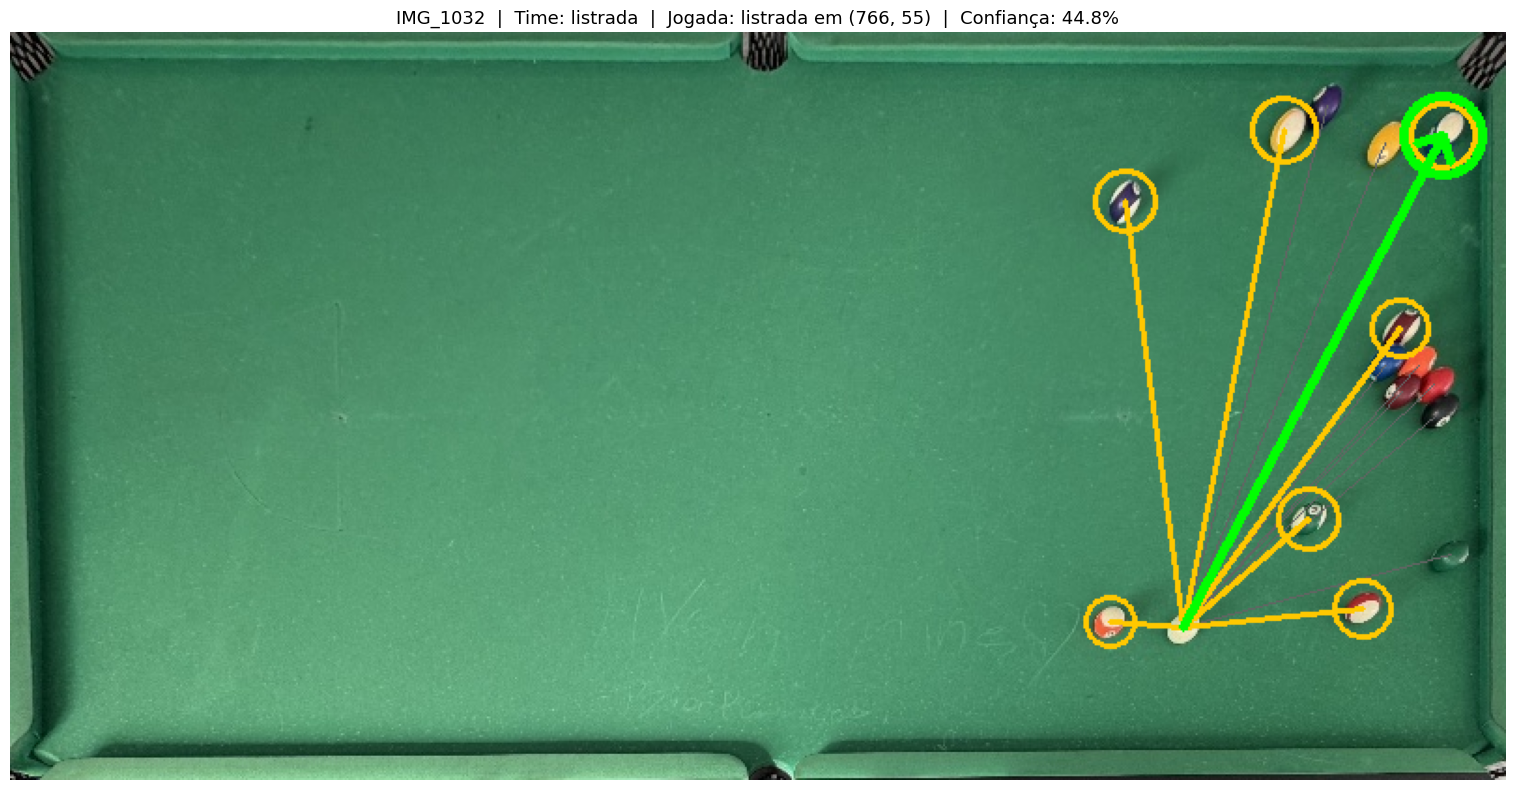

In [10]:
if dados is None or branca is None or bola_sugerida is None:
    print("[AVISO] Sem dados suficientes para visualizar. Rode a Célula 4 primeiro.")
else:
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        print(f"[ERRO] Imagem não encontrada: {caminho_img}")
    else:
        vis = imagem.copy()

        # Linhas cinzas — contexto de todas as bolas
        for bola in todas_sem_branca:
            cv2.line(vis,
                     (branca["x"], branca["y"]),
                     (bola["x"],   bola["y"]),
                     (100, 100, 100), 1)

        # Linhas coloridas — candidatas válidas do meu time
        for bola in candidatas:
            cor = (0, 200, 255) if bola["tipo"] == MEU_TIME else (200, 200, 0)
            cv2.line(vis,
                     (branca["x"], branca["y"]),
                     (bola["x"],   bola["y"]),
                     cor, 2)
            cv2.circle(vis, (bola["x"], bola["y"]),
                       bola.get("raio", 15) + 4, cor, 2)

        # Seta verde — melhor jogada
        cv2.arrowedLine(
            vis,
            (branca["x"],       branca["y"]),
            (bola_sugerida["x"], bola_sugerida["y"]),
            (0, 255, 0), 3, tipLength=0.05
        )
        cv2.circle(vis,
                   (bola_sugerida["x"], bola_sugerida["y"]),
                   bola_sugerida.get("raio", 15) + 8,
                   (0, 255, 0), 3)

        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(
            f"{NOME_IMAGEM}  |  Time: {MEU_TIME}  |  "
            f"Jogada: {bola_sugerida['tipo']} em "
            f"({bola_sugerida['x']}, {bola_sugerida['y']})  |  "
            f"Confiança: {confianca * 100:.1f}%",
            fontsize=13
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()